In [7]:
import sys
sys.path.append("/Users/avelezxerenity/Documents/GitHub/pysdk")
import os
from inflation_query.Inflation_query import implied_inflation_calc
from src.xerenity.xty import Xerenity
from utilities.date_functions import add_months,ql_to_datetime
from utilities.rate_conversion_functions import nom_to_effective
from swap_functions.ibr_quantlib_details import ibr_quantlib_det,ibr_overnight_index,ibr_swap_cupon_helper,depo_helpers_ibr
from swap_functions.ibr_swap_ql_functions import ibr_swaps_quotes,crear_objeto_curva_ibr,fwd_rates_generation
from swap_functions.quotes_query import ibr_mean_query
from swap_functions.main import full_ibr_curve_creation
import pandas as pd
import QuantLib as ql
import plotly.graph_objects as go
from datetime import datetime,date
import matplotlib.pyplot as plt
xty = Xerenity(
    username=os.getenv('XTY_USER'),
    password=os.getenv('XTY_PWD'),
)



#calc_date = ql.Date(2, 11, 2023)
#ql.Settings.instance().evaluationDate = calc_date

2023-11-09 17:24:05,403:INFO - HTTP Request: POST https://tvpehjbqxpiswkqszwwv.supabase.co/auth/v1/token?grant_type=password "HTTP/1.1 200 OK"


## Llamados de las curvas y construccion de la fwd curve

In [13]:
init_date=datetime(2023, 11, 7).date()
final_date=init_date
day_to_avoid_fwd_ois=7
days_to_on=8
curve=full_ibr_curve_creation(init_date,final_date,day_to_avoid_fwd_ois,days_to_on)
start_date=datetime(2023, 12, 15).date()
fwd_curve=fwd_rates_generation(curve,start_date,inverval_tenor=3,interval_period='m')

2023-11-09 17:25:10,612:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/ibr_swaps_cluster?select=%2A "HTTP/1.1 200 OK"
/Users/avelezxerenity/Documents/GitHub/pysdk/src/xerenity/xty.py:133: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/Users/avelezxerenity/Documents/GitHub/pysdk/src/xerenity/xty.py:133: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

2023-11-09 17:25:10,831:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/ibr_swaps_cluster?select=%2A "HTTP/1.1 200 OK"


{'index': 0, 'tenor': 6, 'rate': 0.12204999999999999, 'tenor_unit': 'm'}
{'index': 1, 'tenor': 9, 'rate': 0.11908333333333333, 'tenor_unit': 'm'}
{'index': 2, 'tenor': 24, 'rate': 0.09462000000000001, 'tenor_unit': 'm'}
{'index': 3, 'tenor': 36, 'rate': 0.0877, 'tenor_unit': 'm'}
{'index': 4, 'tenor': 48, 'rate': 0.0843, 'tenor_unit': 'm'}
{'index': 5, 'tenor': 60, 'rate': 0.084086125, 'tenor_unit': 'm'}
{'index': 6, 'tenor': 120, 'rate': 0.083875, 'tenor_unit': 'm'}
tenor to calculate not un curve helper
tenor to calculate not un curve helper
tenor to calculate not un curve helper


In [14]:
fwd_curve

,rate
Maturity Date,
2024-01-15,0.125113
2024-02-15,0.122262
2024-03-15,0.118867
2024-04-15,0.114980
2024-05-15,0.110802
...,...
2033-03-15,0.090147
2033-04-15,0.090708
2033-05-15,0.091299


####ANALISIS historico con las series de tasas de creditos de vivienda

In [15]:
#### Traer la historia del IBR swap. 
ibr_on=pd.DataFrame(xty.BanRep().get_econ_data_last_n(id_serie=15,n=15*365).data).drop('id_serie',axis=1)
ibr_on['fecha'] = pd.to_datetime(ibr_on['fecha'])
ibr_on.set_index('fecha', inplace=True)

cv_tasa=pd.read_csv('historic_non_vis.csv')
cv_tasa.set_index('fecha', inplace=True)

# Assuming df_tpm and df_cv_tasa are your DataFrames
ibr_on.index = pd.to_datetime(ibr_on.index)
cv_tasa.index = pd.to_datetime(cv_tasa.index)
# Resample TPM to daily and forward fill to fill missing values
df_tpm_resampled = ibr_on.resample('D').ffill()

# Merge CV_TASA with TPM using merge_asof
result_df = pd.merge_asof(cv_tasa, df_tpm_resampled, left_index=True, right_index=True, direction='nearest', suffixes=('tasa','valor'))


2023-11-09 17:25:17,588:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/banrep_serie_value?select=%2A&id_serie=eq.15&order=fecha.desc&limit=5475 "HTTP/1.1 200 OK"
/var/folders/t7/tjpkwm2d28sb_3ctgfhx6gr00000gp/T/ipykernel_73182/166599209.py:11: UserWarning:

Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



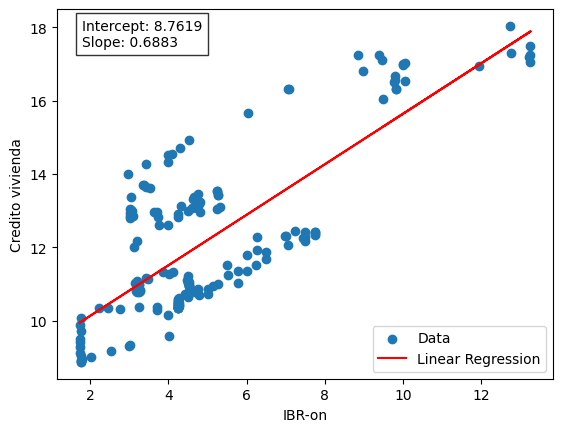

In [16]:
import pandas as pd
import numpy as np


# Drop rows with NaN values
result_df = result_df.dropna(subset=['tasa','valor'])

# Perform linear regression with numpy
X = result_df['valor'].values
y = result_df['tasa'].values

# Add a column of ones for the constant term
X = np.column_stack((np.ones_like(X), X))

# Calculate the coefficients
beta = np.linalg.lstsq(X, y, rcond=None)[0]

# Plot the data and regression line
plt.scatter(result_df['valor'], result_df['tasa'], label='Data')
plt.plot(result_df['valor'], beta[0] + beta[1] * result_df['valor'], color='red', label='Linear Regression')

# Add labels and move legend to the lower right corner
plt.xlabel('IBR-on')
plt.ylabel('Credito vivienda')
plt.legend(loc='lower right')

# Display regression results in a box
plt.text(0.05, 0.9, f'Intercept: {beta[0]:.4f}\nSlope: {beta[1]:.4f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Show the plot
plt.show()

def predict_valor_CV_TASA(ibr_on,slope,intercept):
    # Coefficients from the linear regression
    # intercept = 0.1234
    # slope = 0.5678

    # Use the formula to predict valor_CV_TASA
    predicted_valor_CV_TASA = intercept + slope * ibr_on

    return predicted_valor_CV_TASA





In [17]:
import nbformat
fig = go.Figure()
fig.add_trace(go.Scatter(x=ibr_on['valor'].index, 
                         y=ibr_on['valor'],
                         mode='lines',
                         name='IBR-on historico e.a'))


fig.add_trace(go.Scatter(x=fwd_curve['rate'].index, 
                        y=nom_to_effective(fwd_curve['rate'],365)*100,
                        mode='lines',
                        name='IBR-on implicito e.a'))

fig.add_trace(go.Scatter(x=cv_tasa.index, 
                        y=cv_tasa['tasa'],
                        mode='lines',
                        name='Serie de creditos de vivienda no VIS -Banco de la republica '))
# Add traces for dates after today
fig.add_trace(go.Scatter(x=fwd_curve.index, 
                        y=predict_valor_CV_TASA(nom_to_effective(fwd_curve['rate'],365)*100,beta[1],beta[0]),
                        mode='lines',
                        name='Creditos de vivienda no VIS implicito e.a'))


# Update layout
fig.update_layout(
    title='Tasas IBR overnight y Creditos de vivienda no VIS ',
    xaxis=dict(title='Fechas'),
    yaxis=dict(title='Tasa e.a'),
)
# Show the plot
fig.show()
fig.write_html('/Users/avelezxerenity/Documents/GitHub/wpages/Ibr-on.html')

In [18]:
ibr_on.to_csv('/Users/avelezxerenity/Documents/GitHub/wpages/ibr_ea_historica.csv', index=True)
fwd_curve.to_csv('/Users/avelezxerenity/Documents/GitHub/wpages/ibr_ea_implicita.csv', index=True)
cv_tasa.to_csv('/Users/avelezxerenity/Documents/GitHub/wpages/credito_vivienda_no_vis_ea_historica.csv', index=True)
predict_valor_CV_TASA(nom_to_effective(fwd_curve['rate'],365)*100,beta[1],beta[0]).to_csv('/Users/avelezxerenity/Documents/GitHub/wpages/credito_vivienda_no_vis_ea_implicita.csv', index=True)